# Lifted Markov Transition Analysis

This notebook computes **lifted Markov transition matrices** for intent categories across messages within each chat session (identified by `sha`). The analysis handles multi-label messages via weighted Cartesian product transitions and normalizes via **lift** to counteract base-rate dominance.

**Key concepts:**
- **Weighted Cartesian product**: When consecutive messages have multiple labels, all cross-label pairs are enumerated with weight `1 / (|L_i| × |L_j|)` so each consecutive message pair contributes exactly 1.0 to the total count.
- **Lift**: `lift(i → j) = P(j|i) / P(j)` where `P(j)` is the marginal frequency of category `j`. Lift > 1 indicates reinforcement (category `j` follows `i` more than expected); lift < 1 indicates suppression.

The analysis is performed at both the **main_category** (7 categories) and **sub_category** (20 subcategories, excluding 8.1 Others) levels.

## 1. Imports & Setup

In [1]:
import sys
from pathlib import Path

sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
from itertools import product as cartesian_product
from collections import defaultdict

from intent_classification.categories import VALID_CATEGORIES

RESULTS_DIR = Path("in_session_results")
RESULTS_DIR.mkdir(exist_ok=True)

# Build canonical ordered lists of categories (excluding 8. Others)
MAIN_ORDER = [m for m in VALID_CATEGORIES.keys() if not m.startswith("8.")]
SUB_ORDER = [s for m in MAIN_ORDER for s in VALID_CATEGORIES[m]]

print(f"Main categories ({len(MAIN_ORDER)}): {MAIN_ORDER}")
print(f"Sub categories ({len(SUB_ORDER)}): {SUB_ORDER}")
print(f"Saving figures to: {RESULTS_DIR.resolve()}")

Main categories (7): ['1. Code Authoring', '2. Failure Reporting', '3. Inquiry', '4. Context Specification', '5. Validation', '6. Delegation', '7. Workflow Control']
Sub categories (20): ['1.1 New Implementation', '1.2 Iterative Modification', '1.3 Alignment Correction', '2.1 Log Paste', '2.2 Symptom Description', '2.3 Error Persistence', '3.1 Planning & Decision Consultation', '3.2 Project Comprehension', '3.3 General Knowledge Query', '4.1 Information Injection', '4.2 Behavior Specification', '5.1 Code Review', '5.2 Runtime Inspection', '6.1 Documentation', '6.2 Toolchain Operation', '7.1 Confirmation', '7.2 Continuation', '7.3 Deferred Debugging', '7.4 Deferred Implementation', '7.5 Sentiment Expression']
Saving figures to: /Users/ningzhi_tang/Documents/VSCodeProjects/empirical-conversational-programming/markov_transition/in_session_results


## 2. Data Loading & Filtering

In [2]:
df = pd.read_csv("../data/classifications/classifications_for_analysis.csv")
print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(f"Unique sessions (sha): {df['sha'].nunique()}")
print(f"Unique messages: {df[['sha', 'index_in_chat']].drop_duplicates().shape[0]}")

Loaded 99415 rows
Columns: ['repository_full_name', 'sha', 'timestamp', 'title', 'index_in_chat_original', 'truncated_content', 'labels', 'content', 'label_rank', 'reasoning', 'main_category', 'sub_category', 'index_in_chat']
Unique sessions (sha): 11579
Unique messages: 74998


In [3]:
# Count unique messages per session
msg_per_session = df.groupby("sha")["index_in_chat"].nunique()

# Filter: keep sessions with >= 2 messages
valid_shas = msg_per_session[msg_per_session >= 2].index
df_filtered = df[df["sha"].isin(valid_shas)].copy()

print(f"Sessions before filter: {df['sha'].nunique()}")
print(f"Sessions after filter (>= 2 messages): {len(valid_shas)}")
print(f"Sessions dropped: {df['sha'].nunique() - len(valid_shas)}")
print(f"Rows after filter: {len(df_filtered)}")
print(
    f"Unique messages after filter: {df_filtered[['sha', 'index_in_chat']].drop_duplicates().shape[0]}"
)

Sessions before filter: 11579
Sessions after filter (>= 2 messages): 7742
Sessions dropped: 3837
Rows after filter: 94360
Unique messages after filter: 71161


## 3. Build Per-Message Label Sets

In [4]:
# For each (sha, index_in_chat), collect the set of sub_category and main_category labels
msg_sub_labels = (
    df_filtered.groupby(["sha", "index_in_chat"])["sub_category"]
    .apply(lambda x: tuple(sorted(set(x))))
    .reset_index()
    .rename(columns={"sub_category": "sub_labels"})
)

msg_main_labels = (
    df_filtered.groupby(["sha", "index_in_chat"])["main_category"]
    .apply(lambda x: tuple(sorted(set(x))))
    .reset_index()
    .rename(columns={"main_category": "main_labels"})
)

# Merge into a single message-level dataframe
msg_df = msg_sub_labels.merge(msg_main_labels, on=["sha", "index_in_chat"])
msg_df = msg_df.sort_values(["sha", "index_in_chat"]).reset_index(drop=True)

print(f"Total messages: {len(msg_df)}")
print(f"\nSample multi-label messages:")
multi = msg_df[msg_df["sub_labels"].apply(len) > 1]
print(f"  Multi-label (sub): {len(multi)} ({100*len(multi)/len(msg_df):.1f}%)")
print(multi.head())

Total messages: 71161

Sample multi-label messages:
  Multi-label (sub): 21312 (29.9%)
                                        sha  index_in_chat  \
0  0004983ff9abeb961274a7d5f370e081f34af54a              0   
1  0004983ff9abeb961274a7d5f370e081f34af54a              1   
2  0004983ff9abeb961274a7d5f370e081f34af54a              2   
3  0006d72850c62772199e2b5f19a13badd65db90a              0   
4  0006d72850c62772199e2b5f19a13badd65db90a              1   

                                          sub_labels  \
0  (1.2 Iterative Modification, 2.2 Symptom Descr...   
1  (3.1 Planning & Decision Consultation, 6.1 Doc...   
2  (3.1 Planning & Decision Consultation, 4.2 Beh...   
3  (1.1 New Implementation, 4.1 Information Injec...   
4  (1.2 Iterative Modification, 2.2 Symptom Descr...   

                                         main_labels  
0  (1. Code Authoring, 2. Failure Reporting, 4. C...  
1                        (3. Inquiry, 6. Delegation)  
2  (3. Inquiry, 4. Context Specificati

## 4. Weighted Transition Counting

For each consecutive message pair `(i, j)` within a session:
- Enumerate the Cartesian product `L_i × L_j` of their label sets
- Weight each pair by `1 / (|L_i| × |L_j|)`
- Accumulate into transition count matrix `C[a, b]`

This ensures each consecutive message pair contributes exactly 1.0 to total transition counts.

In [5]:
def compute_weighted_transitions(msg_df, label_col, categories):
    """
    Compute weighted transition counts from consecutive messages.

    Args:
        msg_df: DataFrame with columns ['sha', 'index_in_chat', label_col]
        label_col: column name containing tuple of labels (e.g. 'sub_labels')
        categories: ordered list of category names

    Returns:
        C: transition count matrix (DataFrame, index=source, columns=target)
        total_transitions: total number of consecutive message pairs processed
    """
    cat2idx = {c: i for i, c in enumerate(categories)}
    n = len(categories)
    C = np.zeros((n, n), dtype=np.float64)
    total_transitions = 0

    for sha, group in msg_df.groupby("sha"):
        group = group.sort_values("index_in_chat")
        labels_list = group[label_col].tolist()

        for k in range(len(labels_list) - 1):
            L_i = labels_list[k]
            L_j = labels_list[k + 1]
            weight = 1.0 / (len(L_i) * len(L_j))

            for a, b in cartesian_product(L_i, L_j):
                if a in cat2idx and b in cat2idx:
                    C[cat2idx[a], cat2idx[b]] += weight

            total_transitions += 1

    C_df = pd.DataFrame(C, index=categories, columns=categories)
    return C_df, total_transitions


# Compute transitions at both levels
C_sub, n_trans_sub = compute_weighted_transitions(msg_df, "sub_labels", SUB_ORDER)
C_main, n_trans_main = compute_weighted_transitions(msg_df, "main_labels", MAIN_ORDER)

print(f"Total consecutive message pairs: {n_trans_sub}")
print(
    f"\nSub-category transition count matrix sum: {C_sub.values.sum():.1f} (should ≈ {n_trans_sub})"
)
print(
    f"Main-category transition count matrix sum: {C_main.values.sum():.1f} (should ≈ {n_trans_main})"
)

Total consecutive message pairs: 63419

Sub-category transition count matrix sum: 63419.0 (should ≈ 63419)
Main-category transition count matrix sum: 63419.0 (should ≈ 63419)


## 5. Marginal Frequencies

Compute `P(j)` — the marginal frequency of each category. Each message contributes `1/|labels|` to each of its labels' marginal counts, so marginals sum to 1 per message (consistent with the transition weighting).

In [6]:
def compute_marginals(msg_df, label_col, categories):
    """
    Compute marginal frequency P(j) for each category, weighted by 1/|labels| per message.
    """
    counts = defaultdict(float)
    total = 0.0

    for labels in msg_df[label_col]:
        w = 1.0 / len(labels)
        for label in labels:
            counts[label] += w
        total += 1.0

    marginals = pd.Series(
        {c: counts.get(c, 0.0) / total for c in categories}, dtype=np.float64
    )
    return marginals


P_sub = compute_marginals(msg_df, "sub_labels", SUB_ORDER)
P_main = compute_marginals(msg_df, "main_labels", MAIN_ORDER)

print(f"Sub-category marginals sum: {P_sub.sum():.6f} (should be 1.0)")
print(f"Main-category marginals sum: {P_main.sum():.6f} (should be 1.0)")
print(f"\nSub-category marginals:")
print(P_sub.to_string())
print(f"\nMain-category marginals:")
print(P_main.to_string())

Sub-category marginals sum: 1.000000 (should be 1.0)
Main-category marginals sum: 1.000000 (should be 1.0)

Sub-category marginals:
1.1 New Implementation                  0.040598
1.2 Iterative Modification              0.191163
1.3 Alignment Correction                0.043156
2.1 Log Paste                           0.070416
2.2 Symptom Description                 0.109756
2.3 Error Persistence                   0.027864
3.1 Planning & Decision Consultation    0.063763
3.2 Project Comprehension               0.070993
3.3 General Knowledge Query             0.033635
4.1 Information Injection               0.057538
4.2 Behavior Specification              0.036002
5.1 Code Review                         0.019717
5.2 Runtime Inspection                  0.008293
6.1 Documentation                       0.047401
6.2 Toolchain Operation                 0.077818
7.1 Confirmation                        0.024774
7.2 Continuation                        0.052720
7.3 Deferred Debugging             

## 6. Conditional Probabilities & Lift

- **Conditional**: $P(j|i) = \frac{C(i \to j)}{\sum_k C(i \to k)}$
- **Lift**: $\text{lift}(i \to j) = \frac{P(j|i)}{P(j)}$

In [7]:
def compute_conditional_and_lift(C_df, marginals):
    """
    Compute conditional probability P(j|i) and lift matrix from transition counts.

    Returns:
        P_cond: conditional probability matrix (rows sum to 1)
        lift: lift matrix
    """
    # Row-normalize to get P(j|i)
    row_sums = C_df.sum(axis=1)
    # Avoid division by zero for rows with no outgoing transitions
    P_cond = C_df.div(row_sums, axis=0).fillna(0)

    # Compute lift = P(j|i) / P(j)
    # Avoid division by zero for categories with zero marginal
    lift = P_cond.div(marginals, axis=1)
    lift = lift.replace([np.inf, -np.inf], np.nan)

    return P_cond, lift


P_cond_sub, lift_sub = compute_conditional_and_lift(C_sub, P_sub)
P_cond_main, lift_main = compute_conditional_and_lift(C_main, P_main)

# Sanity checks
print("Row sums of P(j|i) — sub_category (should all be 1.0):")
print(P_cond_sub.sum(axis=1).round(6).to_string())
print(f"\nRow sums of P(j|i) — main_category (should all be 1.0):")
print(P_cond_main.sum(axis=1).round(6).to_string())

Row sums of P(j|i) — sub_category (should all be 1.0):
1.1 New Implementation                  1.0
1.2 Iterative Modification              1.0
1.3 Alignment Correction                1.0
2.1 Log Paste                           1.0
2.2 Symptom Description                 1.0
2.3 Error Persistence                   1.0
3.1 Planning & Decision Consultation    1.0
3.2 Project Comprehension               1.0
3.3 General Knowledge Query             1.0
4.1 Information Injection               1.0
4.2 Behavior Specification              1.0
5.1 Code Review                         1.0
5.2 Runtime Inspection                  1.0
6.1 Documentation                       1.0
6.2 Toolchain Operation                 1.0
7.1 Confirmation                        1.0
7.2 Continuation                        1.0
7.3 Deferred Debugging                  1.0
7.4 Deferred Implementation             1.0
7.5 Sentiment Expression                1.0

Row sums of P(j|i) — main_category (should all be 1.0):
1. Code 

In [8]:
# Persist only the required artifacts for downstream comparisons
TRANSITION_DATA_DIR = RESULTS_DIR / "transition_matrices"
TRANSITION_DATA_DIR.mkdir(parents=True, exist_ok=True)


def save_required_outputs(level_key, lift_df, marginals):
    """Save only lift matrix and marginals for a level (main/sub)."""
    level_dir = TRANSITION_DATA_DIR / level_key
    level_dir.mkdir(parents=True, exist_ok=True)

    lift_df.to_csv(level_dir / "transition_lift.csv", index=True)
    marginals.rename("marginal").to_csv(level_dir / "marginals.csv", index=True)

    return level_dir


main_dir = save_required_outputs("main_category", lift_main, P_main)
sub_dir = save_required_outputs("sub_category", lift_sub, P_sub)

print(f"Saved required artifacts to: {TRANSITION_DATA_DIR.resolve()}")
print("Each level now saves only: transition_lift.csv, marginals.csv")
print(f"- Main category files: {main_dir}")
print(f"- Sub category files: {sub_dir}")

Saved required artifacts to: /Users/ningzhi_tang/Documents/VSCodeProjects/empirical-conversational-programming/markov_transition/in_session_results/transition_matrices
Each level now saves only: transition_lift.csv, marginals.csv
- Main category files: in_session_results/transition_matrices/main_category
- Sub category files: in_session_results/transition_matrices/sub_category


## 7. Heatmaps — Main Category Level

In [9]:
# Short labels for display
def short_label(label):
    """Extract short label: '1. Code Authoring' -> '1. Code Auth.' etc."""
    return label


def short_sub_label(label):
    """Extract short sub-label: '1.1 New Implementation' -> '1.1 New Impl.'"""
    return label

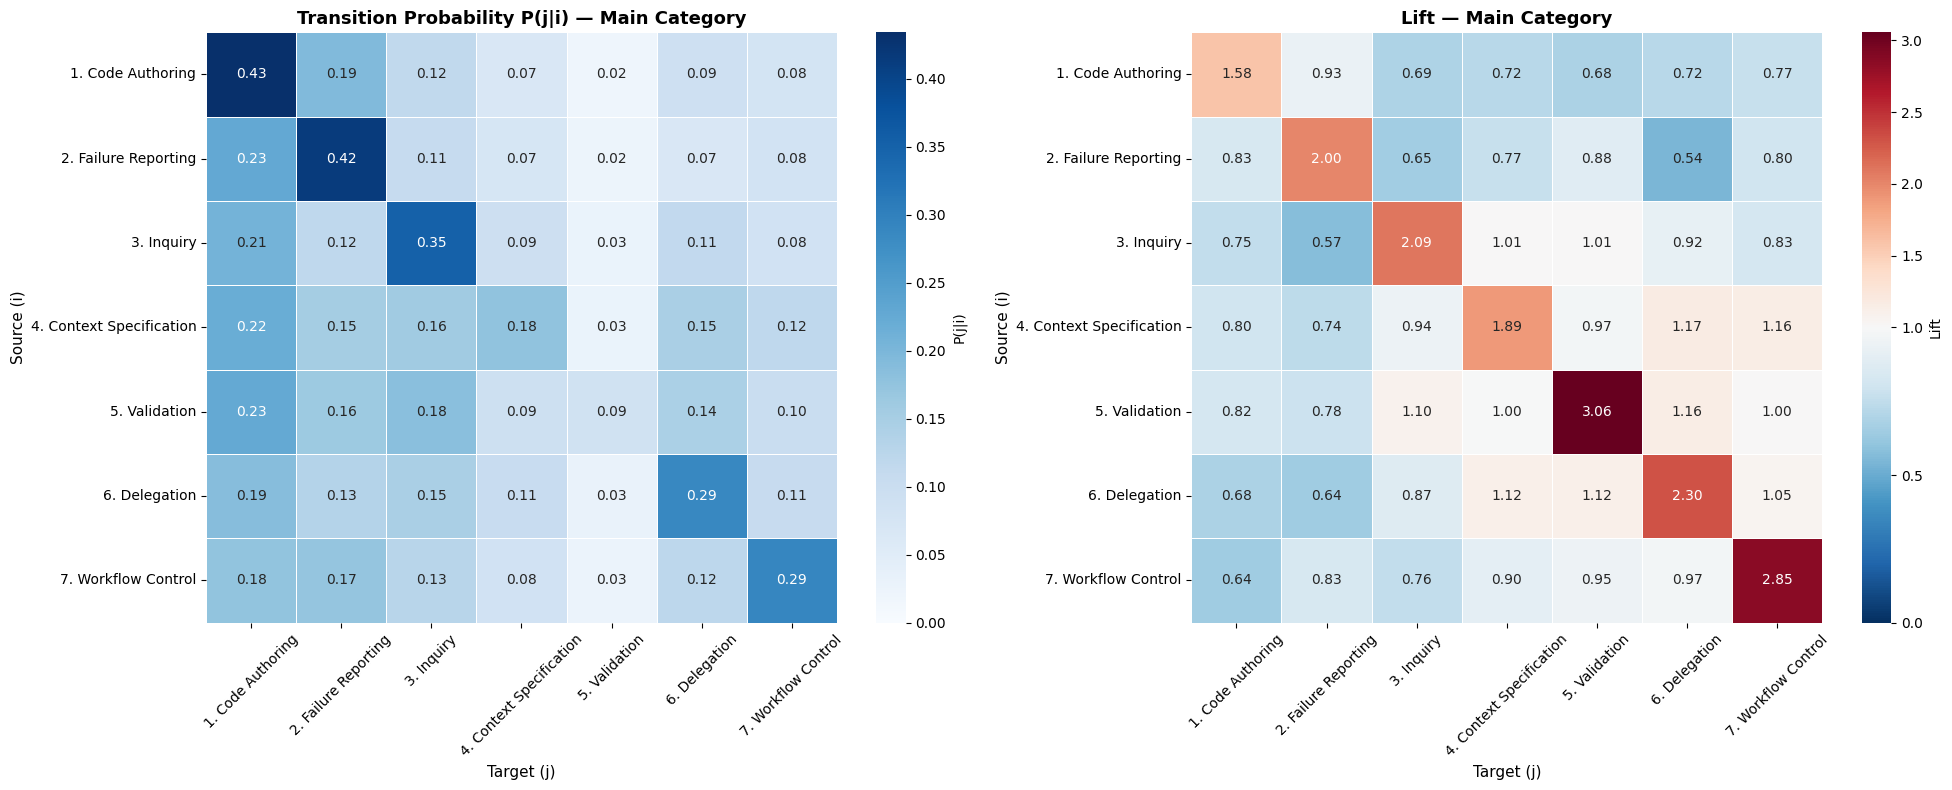

In [10]:
def plot_heatmaps(P_cond, lift, categories, level_name, figsize=(18, 7)):
    """Plot transition probability and lift heatmaps side by side."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # --- Transition Probability Heatmap ---
    ax = axes[0]
    sns.heatmap(
        P_cond,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=categories,
        yticklabels=categories,
        ax=ax,
        vmin=0,
        cbar_kws={"label": "P(j|i)"},
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_title(
        f"Transition Probability P(j|i) — {level_name}", fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Target (j)", fontsize=11)
    ax.set_ylabel("Source (i)", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

    # --- Lift Heatmap ---
    ax = axes[1]

    # Diverging colormap centered at 1.0
    lift_vals = lift.values[~np.isnan(lift.values)]
    vmax = max(abs(lift_vals.max()), abs(lift_vals.min()), 2)
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1.0, vmax=min(vmax, 5))

    sns.heatmap(
        lift,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        norm=norm,
        xticklabels=categories,
        yticklabels=categories,
        ax=ax,
        cbar_kws={"label": "Lift"},
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_title(f"Lift — {level_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Target (j)", fontsize=11)
    ax.set_ylabel("Source (i)", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f"heatmap_{level_name.lower().replace(' ', '_')}.pdf",
        bbox_inches="tight",
        dpi=150,
    )
    plt.show()


plot_heatmaps(P_cond_main, lift_main, MAIN_ORDER, "Main Category", figsize=(20, 8))

## 8. Heatmaps — Sub-Category Level

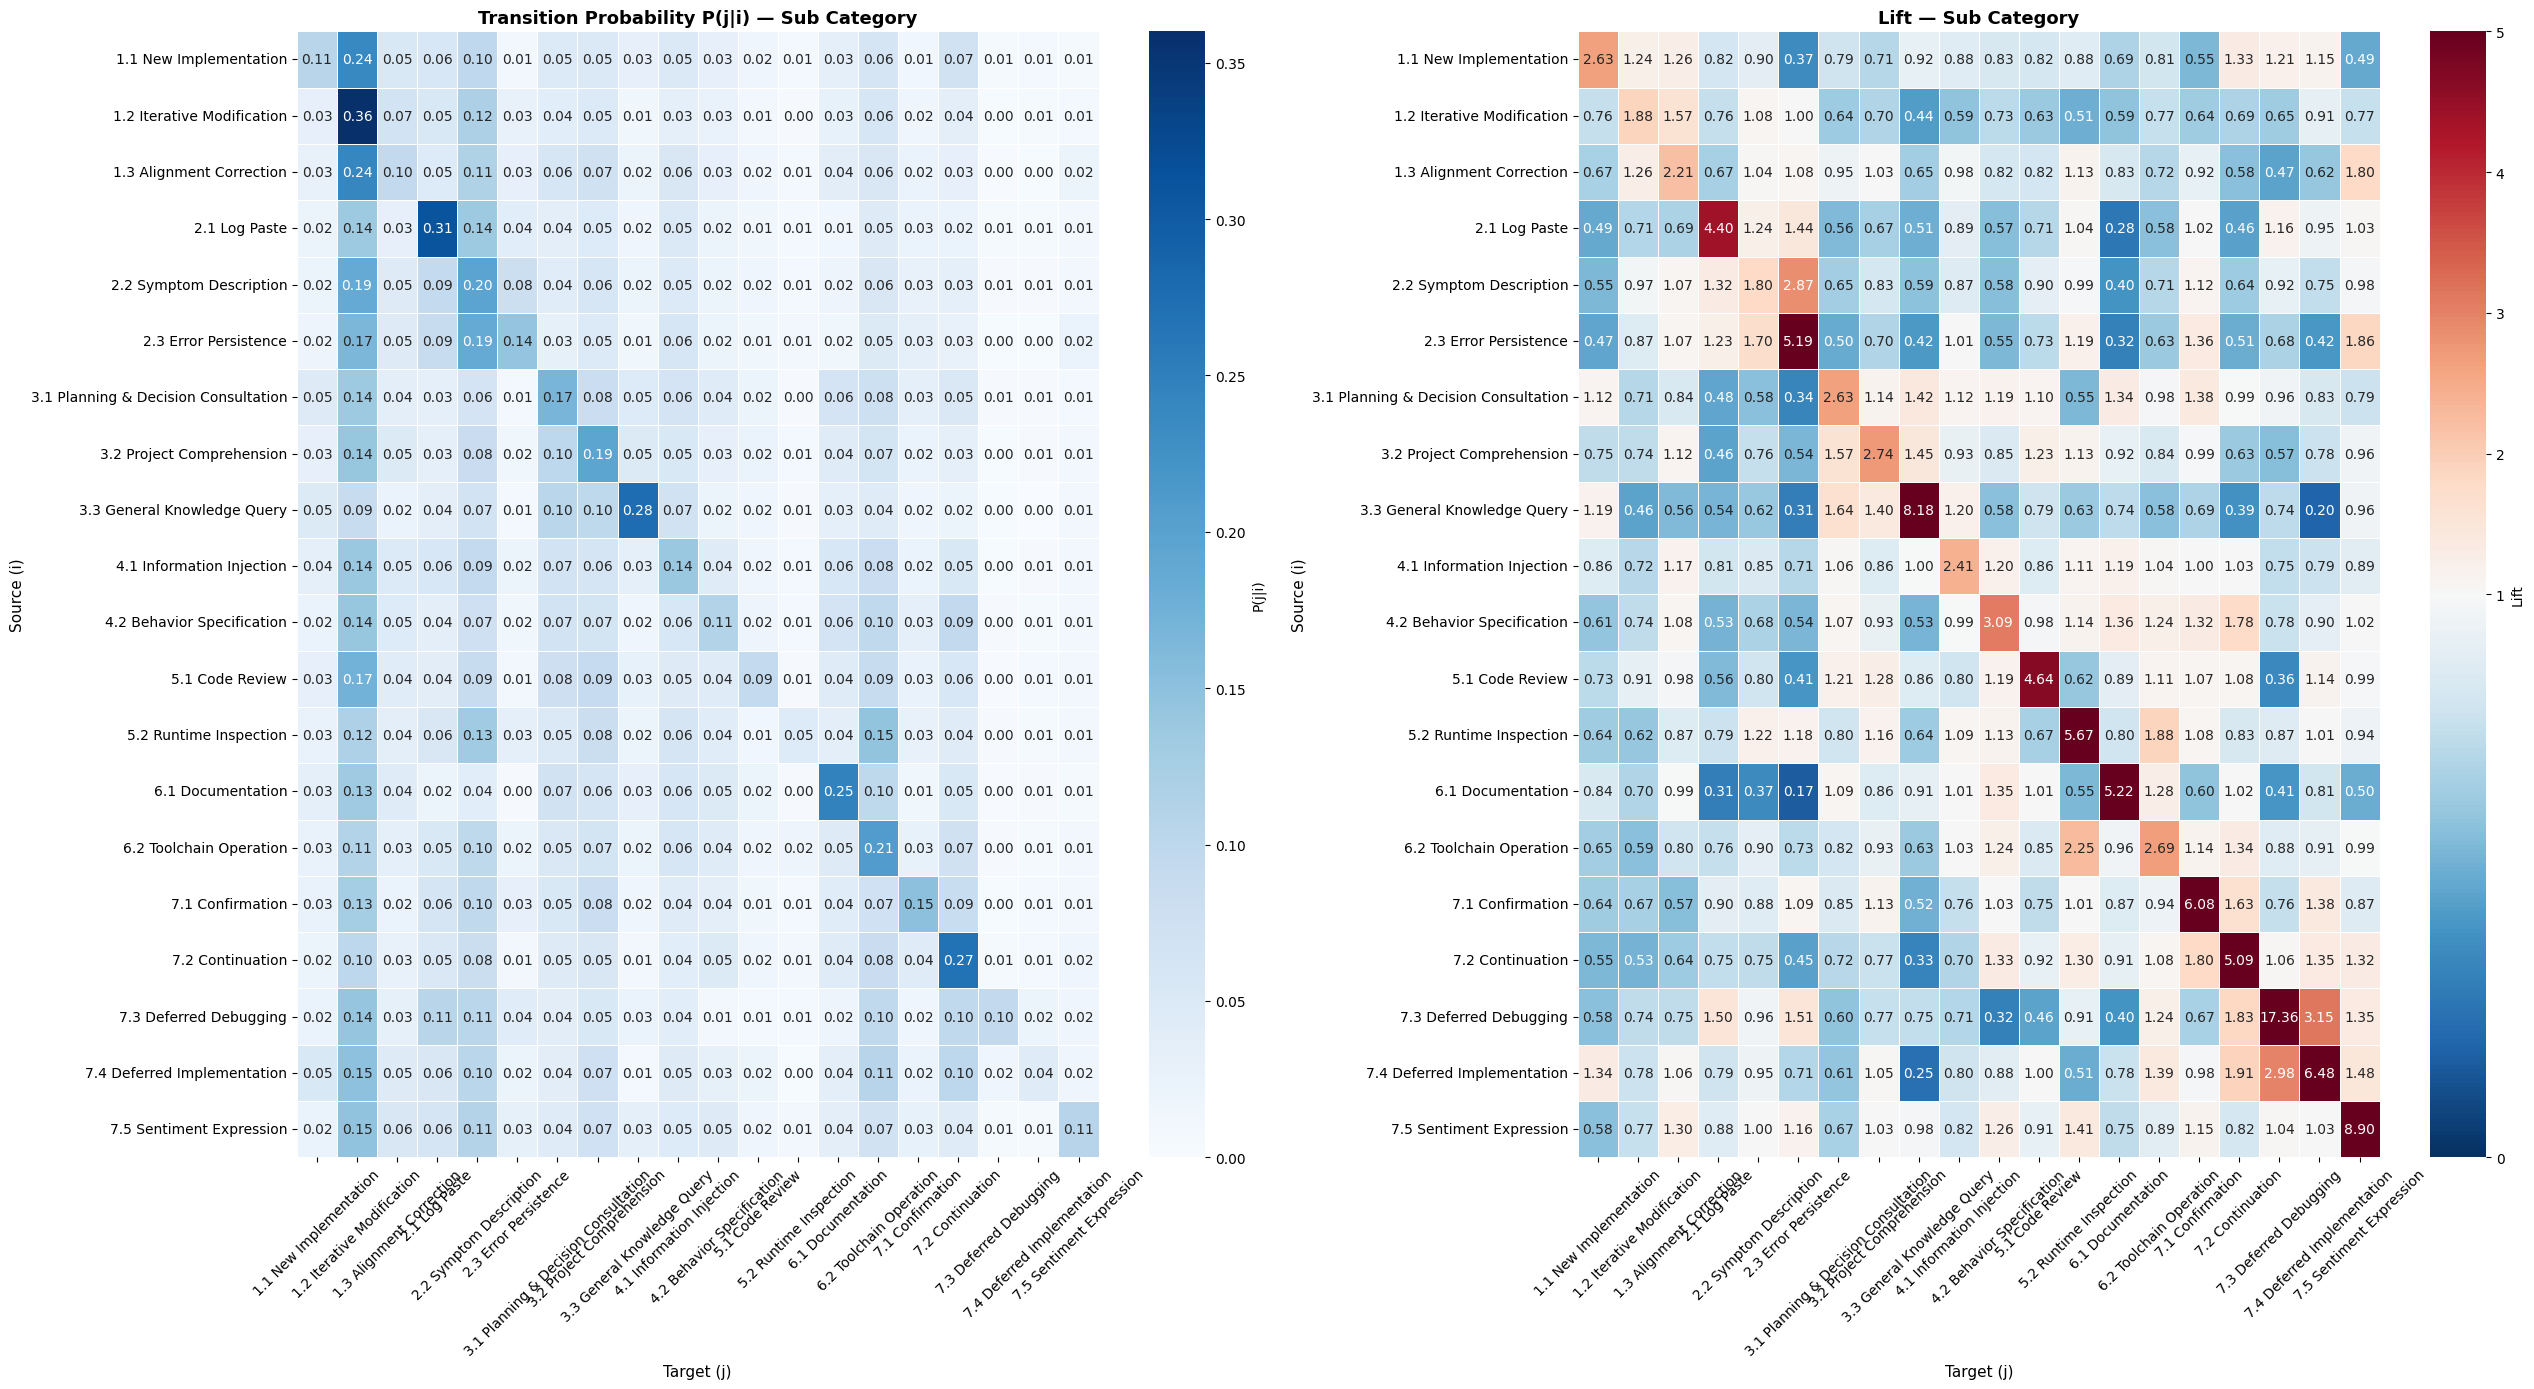

In [11]:
plot_heatmaps(P_cond_sub, lift_sub, SUB_ORDER, "Sub Category", figsize=(26, 14))

## 9. Network Graph — Main Category Level

Directed graph where:
- **Node size** ∝ marginal frequency `P(j)`
- **Edge width** ∝ transition probability `P(j|i)`
- **Edge color intensity** ∝ lift
- Low-probability edges are filtered out for readability

In [12]:
# Color palette for main categories
MAIN_COLORS = {
    "1. Code Authoring": "#4C72B0",
    "2. Failure Reporting": "#C44E52",
    "3. Inquiry": "#55A868",
    "4. Context Specification": "#DD8452",
    "5. Validation": "#8172B3",
    "6. Delegation": "#937860",
    "7. Workflow Control": "#DA8BC3",
}

# Map sub-categories to their main category color
SUB_COLORS = {}
for main_cat, subs in VALID_CATEGORIES.items():
    if main_cat in MAIN_COLORS:
        for sub in subs:
            SUB_COLORS[sub] = MAIN_COLORS[main_cat]

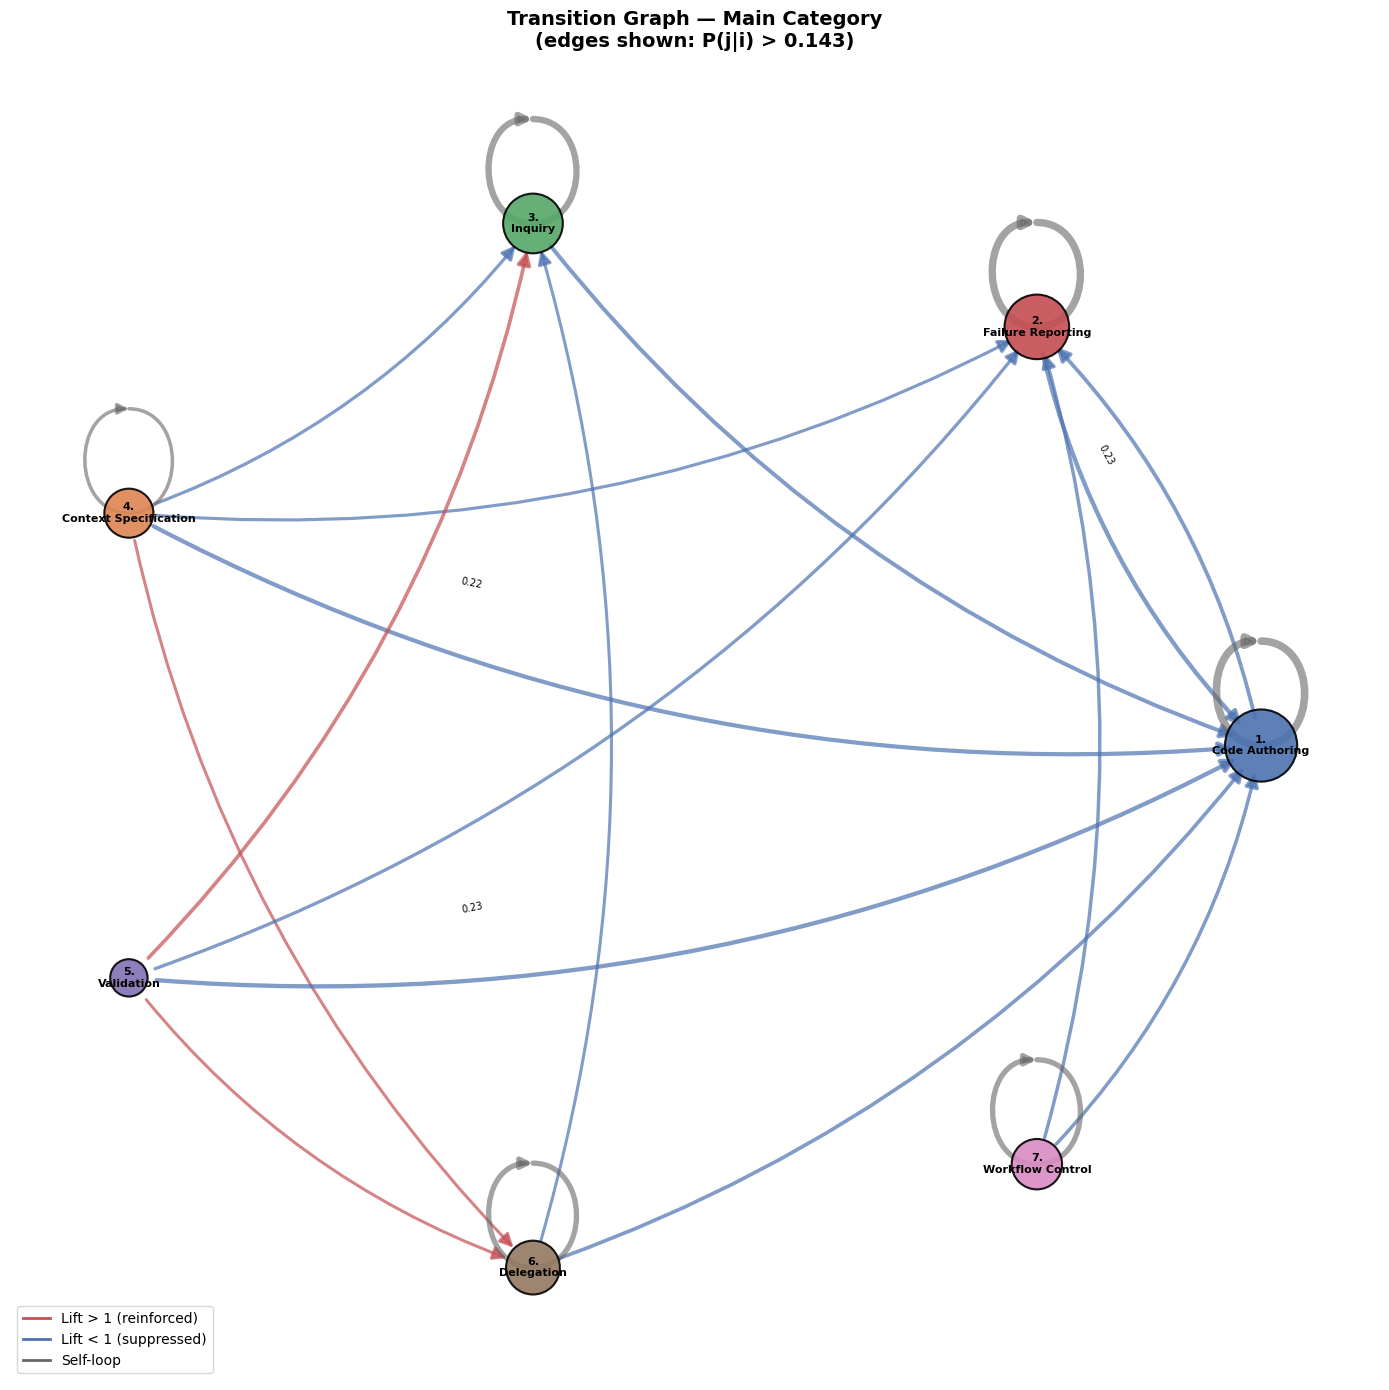


Graph stats: 7 nodes, 21 edges
Edge threshold: P(j|i) > 0.143


In [13]:
def plot_transition_graph(
    P_cond,
    lift_matrix,
    marginals,
    categories,
    colors,
    level_name,
    edge_threshold=None,
    figsize=(14, 14),
):
    """
    Plot a directed transition graph.

    Args:
        P_cond: conditional probability matrix
        lift_matrix: lift matrix
        marginals: marginal frequencies
        categories: ordered list of category names
        colors: dict mapping category -> color
        level_name: string for title
        edge_threshold: minimum P(j|i) to show an edge (auto-computed if None)
    """
    G = nx.DiGraph()

    # Add nodes
    for cat in categories:
        G.add_node(cat, weight=marginals[cat])

    # Auto-compute threshold: keep edges above 1/N (uniform baseline)
    if edge_threshold is None:
        edge_threshold = 1.0 / len(categories)

    # Add edges above threshold
    for src in categories:
        for tgt in categories:
            p = P_cond.loc[src, tgt]
            if p > edge_threshold:
                lft = lift_matrix.loc[src, tgt]
                G.add_edge(src, tgt, weight=p, lift=lft if not np.isnan(lft) else 1.0)

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Layout
    pos = nx.circular_layout(G)

    # Node sizes proportional to marginal frequency
    node_sizes = [marginals[cat] * 8000 + 500 for cat in G.nodes()]
    node_colors = [colors.get(cat, "#CCCCCC") for cat in G.nodes()]

    # Draw nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.9,
        edgecolors="black",
        linewidths=1.5,
    )

    # Draw labels
    # Wrap labels for readability
    wrapped = {n: n.replace(" ", "\n", 1) for n in G.nodes()}
    nx.draw_networkx_labels(
        G, pos, labels=wrapped, ax=ax, font_size=8, font_weight="bold"
    )

    # Draw edges with varying width
    edges = G.edges(data=True)
    if edges:
        weights = [d["weight"] for _, _, d in edges]
        max_w = max(weights) if weights else 1

        # Separate self-loops from other edges for different drawing
        self_loops = [(u, v, d) for u, v, d in edges if u == v]
        other_edges = [(u, v, d) for u, v, d in edges if u != v]

        # Draw non-self-loop edges
        if other_edges:
            edge_widths = [d["weight"] / max_w * 5 + 0.5 for _, _, d in other_edges]
            edge_colors_list = []
            for _, _, d in other_edges:
                lft = d["lift"]
                if lft > 1:
                    edge_colors_list.append("#C44E52")  # Red for lift > 1
                else:
                    edge_colors_list.append("#4C72B0")  # Blue for lift < 1

            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=[(u, v) for u, v, _ in other_edges],
                width=edge_widths,
                edge_color=edge_colors_list,
                alpha=0.7,
                arrows=True,
                arrowsize=20,
                connectionstyle="arc3,rad=0.15",
                ax=ax,
                min_source_margin=20,
                min_target_margin=20,
            )

        # Draw self-loops
        if self_loops:
            self_widths = [d["weight"] / max_w * 5 + 0.5 for _, _, d in self_loops]
            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=[(u, v) for u, v, _ in self_loops],
                width=self_widths,
                edge_color="#666666",
                alpha=0.6,
                arrows=True,
                arrowsize=15,
                ax=ax,
                min_source_margin=20,
                min_target_margin=20,
            )

        # Edge labels for significant transitions
        edge_labels = {}
        for u, v, d in edges:
            if d["weight"] > edge_threshold * 1.5:  # Only label bigger edges
                edge_labels[(u, v)] = f"{d['weight']:.2f}"
        if other_edges:  # Only draw edge labels for non-self-loops
            non_self_labels = {k: v for k, v in edge_labels.items() if k[0] != k[1]}
            nx.draw_networkx_edge_labels(
                G, pos, edge_labels=non_self_labels, ax=ax, font_size=7, label_pos=0.3
            )

    ax.set_title(
        f"Transition Graph — {level_name}\n(edges shown: P(j|i) > {edge_threshold:.3f})",
        fontsize=14,
        fontweight="bold",
    )

    # Legend for edge colors
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D([0], [0], color="#C44E52", lw=2, label="Lift > 1 (reinforced)"),
        Line2D([0], [0], color="#4C72B0", lw=2, label="Lift < 1 (suppressed)"),
        Line2D([0], [0], color="#666666", lw=2, label="Self-loop"),
    ]
    ax.legend(handles=legend_elements, loc="lower left", fontsize=10)

    ax.axis("off")
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f"graph_{level_name.lower().replace(' ', '_')}.pdf",
        bbox_inches="tight",
        dpi=150,
    )
    plt.show()

    print(f"\nGraph stats: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print(f"Edge threshold: P(j|i) > {edge_threshold:.3f}")


plot_transition_graph(
    P_cond_main,
    lift_main,
    P_main,
    MAIN_ORDER,
    MAIN_COLORS,
    "Main Category",
    figsize=(14, 14),
)

## 10. Network Graph — Sub-Category Level

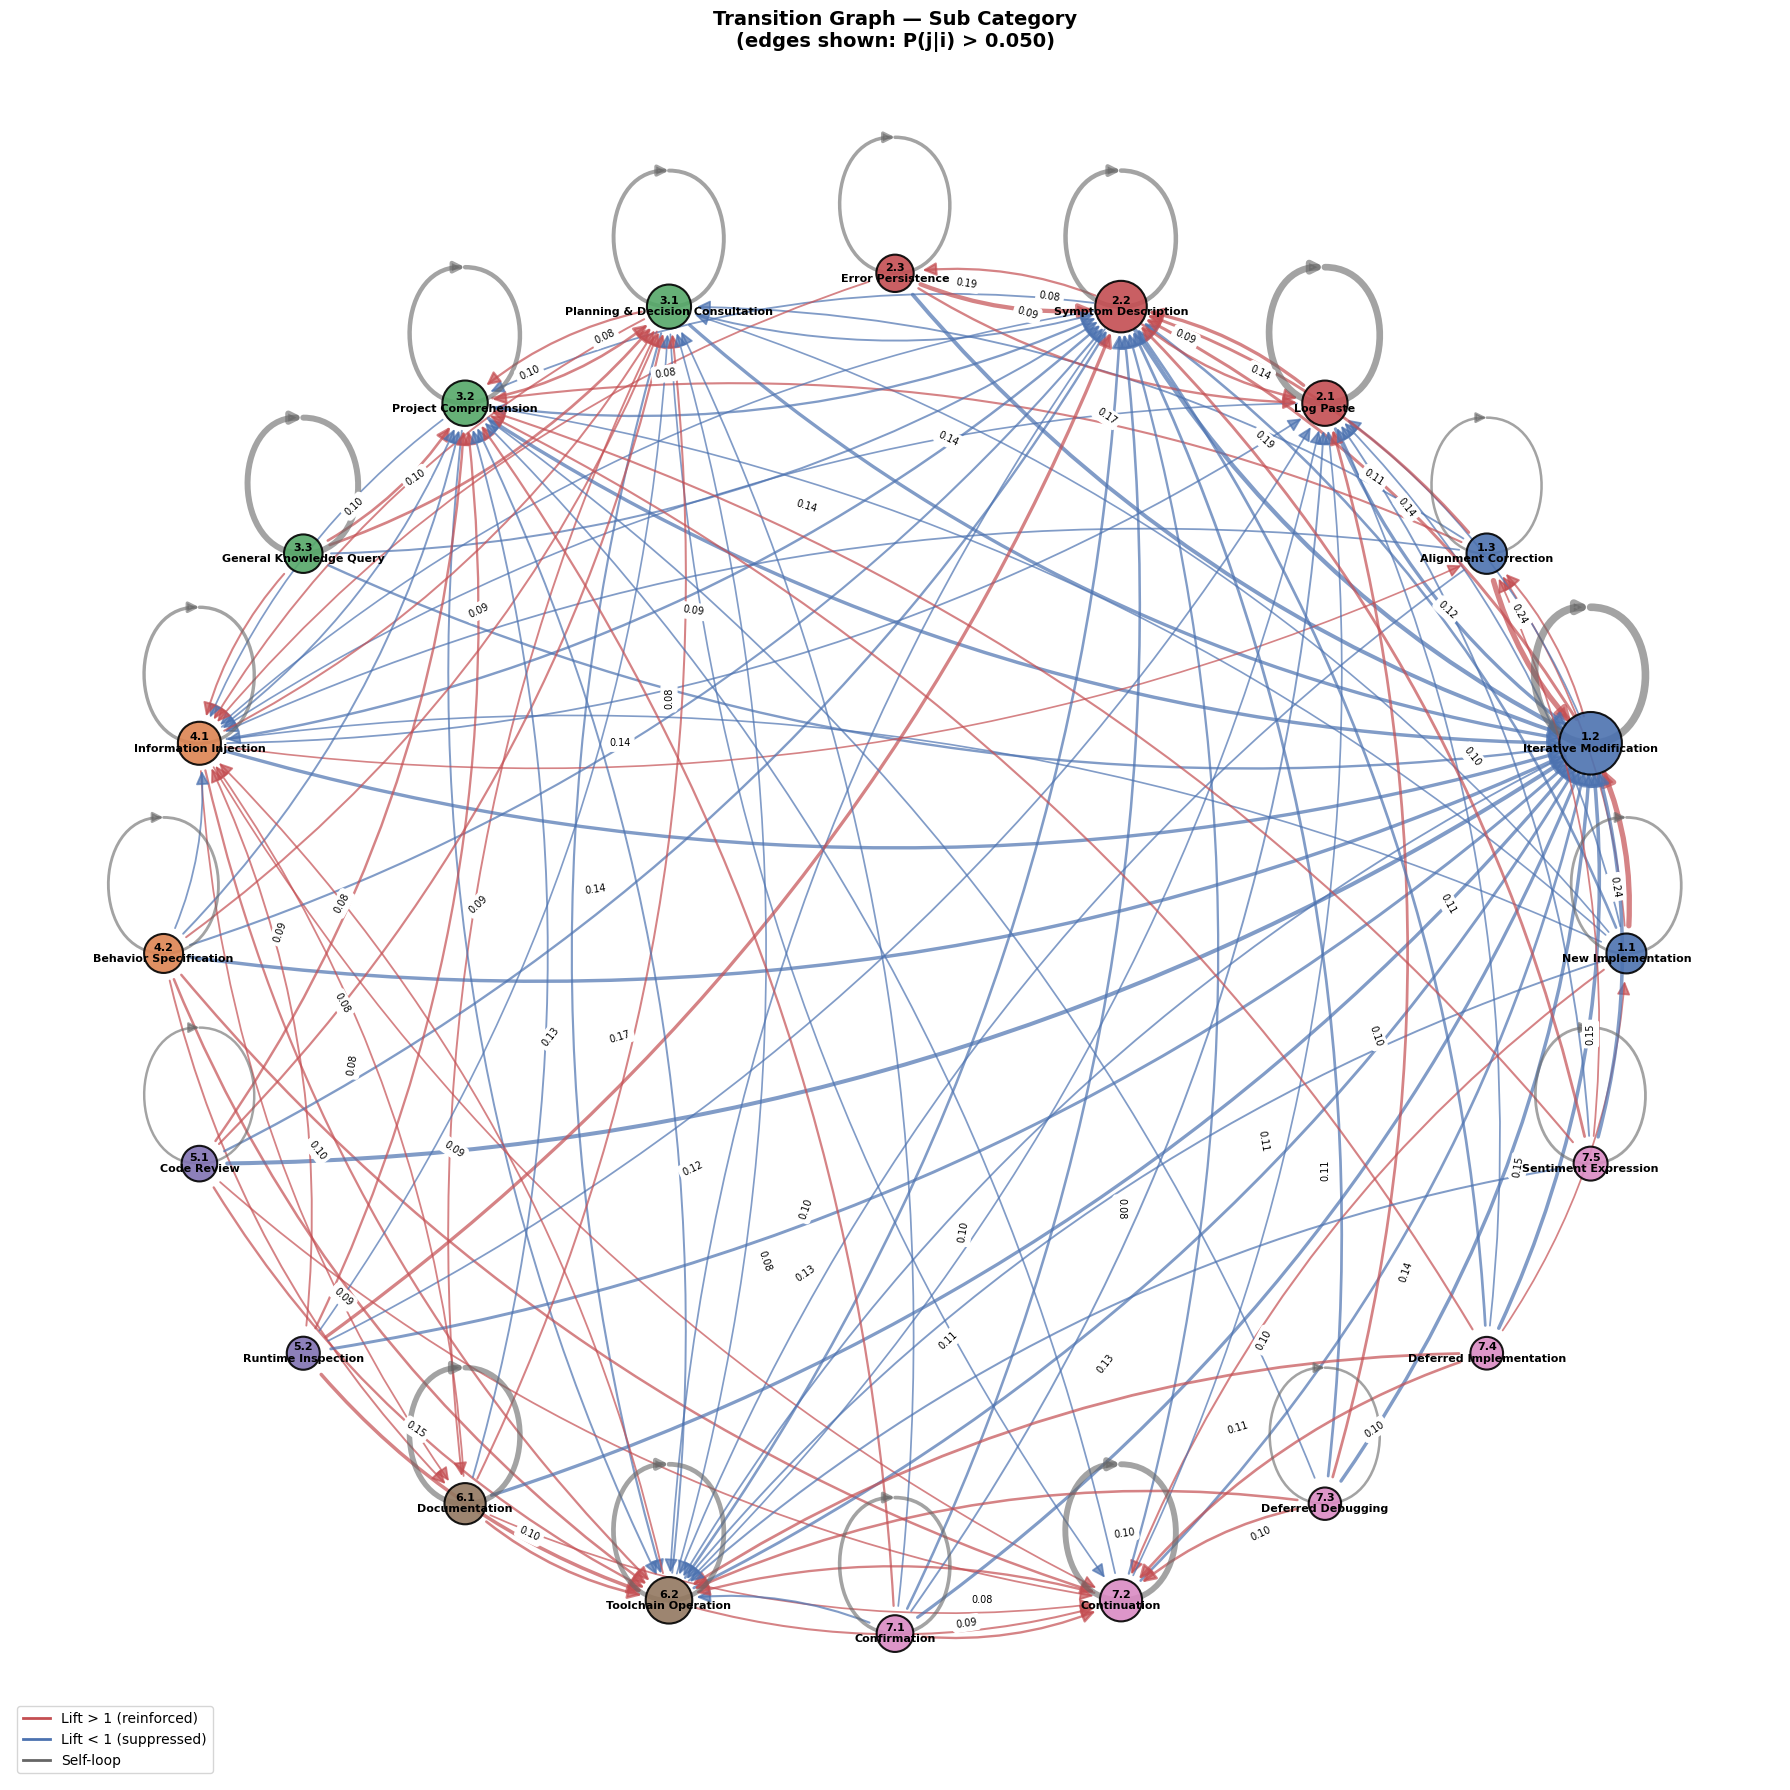


Graph stats: 20 nodes, 141 edges
Edge threshold: P(j|i) > 0.050


In [14]:
plot_transition_graph(
    P_cond_sub, lift_sub, P_sub, SUB_ORDER, SUB_COLORS, "Sub Category", figsize=(18, 18)
)

## 11. Top-N Transitions by Lift

Print the top transitions sorted by lift, clearly marking whether each is:
- **Diagonal** (self-loop): source == target category
- **Non-diagonal** (cross-category): source ≠ target category

In [15]:
def build_transition_table(P_cond, lift_matrix, C_df, categories, level_name, top_n=20):
    """
    Build and display a sorted table of transitions.
    """
    records = []
    for src in categories:
        for tgt in categories:
            p = P_cond.loc[src, tgt]
            lft = lift_matrix.loc[src, tgt]
            c = C_df.loc[src, tgt]
            is_diag = "diagonal" if src == tgt else "non-diagonal"
            records.append(
                {
                    "source": src,
                    "target": tgt,
                    "count": round(c, 2),
                    "P(j|i)": round(p, 4),
                    "lift": round(lft, 4) if not np.isnan(lft) else np.nan,
                    "type": is_diag,
                }
            )

    table = pd.DataFrame(records)
    # Filter out zero-count transitions
    table = table[table["count"] > 0].copy()
    table = table.sort_values("lift", ascending=False).reset_index(drop=True)

    print(f"\n{'='*100}")
    print(f"Top {top_n} Transitions by Lift — {level_name}")
    print(f"{'='*100}")
    print(table.head(top_n).to_string(index=False))

    print(f"\n{'='*100}")
    print(f"Bottom {top_n} Transitions by Lift — {level_name} (most suppressed)")
    print(f"{'='*100}")
    print(table.tail(top_n).to_string(index=False))

    # Summary stats
    n_diag = (table["type"] == "diagonal").sum()
    n_nondiag = (table["type"] == "non-diagonal").sum()
    top_diag = table[table["type"] == "diagonal"].head(top_n)
    top_nondiag = table[table["type"] == "non-diagonal"].head(top_n)

    print(f"\n{'='*100}")
    print(f"Top {top_n} DIAGONAL (self-loop) Transitions — {level_name}")
    print(f"{'='*100}")
    print(top_diag.to_string(index=False))

    print(f"\n{'='*100}")
    print(f"Top {top_n} NON-DIAGONAL (cross-category) Transitions — {level_name}")
    print(f"{'='*100}")
    print(top_nondiag.to_string(index=False))

    print(
        f"\nTotal non-zero transitions: {len(table)} ({n_diag} diagonal, {n_nondiag} non-diagonal)"
    )

    return table

In [16]:
table_main = build_transition_table(
    P_cond_main, lift_main, C_main, MAIN_ORDER, "Main Category", top_n=20
)


Top 20 Transitions by Lift — Main Category
                  source                   target   count  P(j|i)   lift         type
           5. Validation            5. Validation  155.26  0.0858 3.0551     diagonal
     7. Workflow Control      7. Workflow Control 1837.26  0.2909 2.8489     diagonal
           6. Delegation            6. Delegation 2152.17  0.2880 2.3020     diagonal
              3. Inquiry               3. Inquiry 3893.47  0.3525 2.0920     diagonal
    2. Failure Reporting     2. Failure Reporting 5488.39  0.4153 1.9976     diagonal
4. Context Specification 4. Context Specification 1064.26  0.1765 1.8867     diagonal
       1. Code Authoring        1. Code Authoring 7609.64  0.4342 1.5799     diagonal
4. Context Specification            6. Delegation  882.90  0.1464 1.1702 non-diagonal
4. Context Specification      7. Workflow Control  714.06  0.1184 1.1597 non-diagonal
           5. Validation            6. Delegation  262.43  0.1450 1.1590 non-diagonal
          

In [17]:
table_sub = build_transition_table(
    P_cond_sub, lift_sub, C_sub, SUB_ORDER, "Sub Category", top_n=20
)


Top 20 Transitions by Lift — Sub Category
                              source                               target   count  P(j|i)    lift         type
              7.3 Deferred Debugging               7.3 Deferred Debugging   31.50  0.0956 17.3618     diagonal
            7.5 Sentiment Expression             7.5 Sentiment Expression   80.50  0.1081  8.8971     diagonal
         3.3 General Knowledge Query          3.3 General Knowledge Query  605.58  0.2752  8.1827     diagonal
         7.4 Deferred Implementation          7.4 Deferred Implementation   18.17  0.0436  6.4750     diagonal
                    7.1 Confirmation                     7.1 Confirmation  234.58  0.1506  6.0788     diagonal
              5.2 Runtime Inspection               5.2 Runtime Inspection   25.42  0.0470  5.6717     diagonal
                   6.1 Documentation                    6.1 Documentation  679.37  0.2473  5.2168     diagonal
               2.3 Error Persistence                2.3 Error Persist

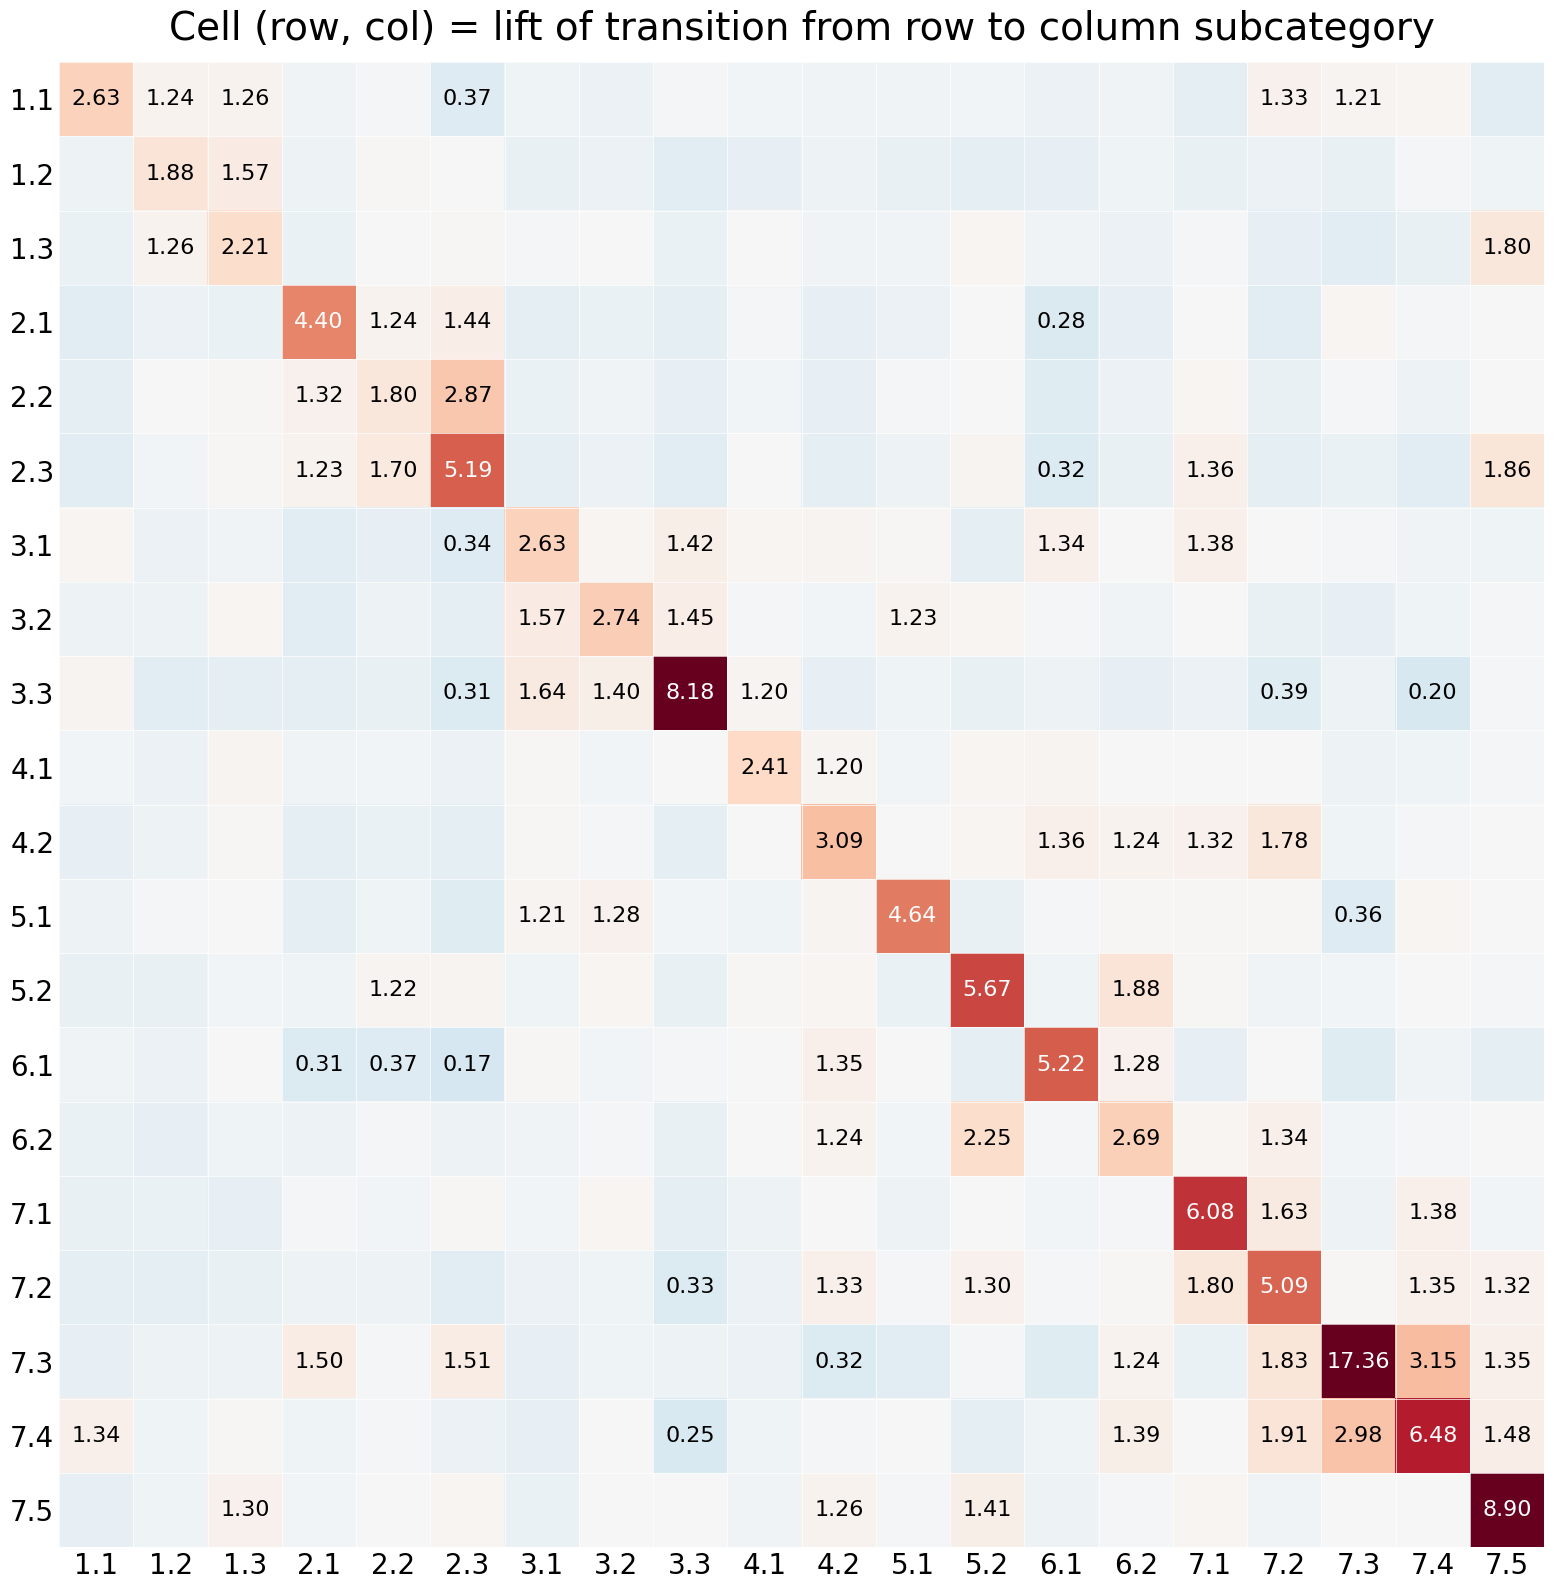

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

lift_cap = 8.0
text_white_threshold = 4.0

# -- Prepare data --
lift_arr = lift_sub.values.copy()
n = lift_arr.shape[0]

lift_display = np.where(
    np.isfinite(lift_arr),
    np.clip(lift_arr, 0, lift_cap),
    np.nan,
)

short_labels = [label.split(" ", 1)[0] for label in SUB_ORDER]

cmap = plt.cm.RdBu_r  # red = high lift, blue = suppressed, white = 1.0

# -- Plot --
fig, ax = plt.subplots(figsize=(16, 16))

# Center white at lift = 1.0
norm = mcolors.TwoSlopeNorm(vmin=-lift_cap // 2, vcenter=1.0, vmax=lift_cap)

im = ax.imshow(
    lift_display,
    cmap=cmap,
    norm=norm,
    aspect="equal",
)

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(n + 1):
    ax.axhline(i - 0.5, color="white", linewidth=0.5, zorder=2)
    ax.axvline(i - 0.5, color="white", linewidth=0.5, zorder=2)

for i in range(n):
    for j in range(n):
        val = lift_arr[i, j]
        if not np.isfinite(val) or 0.4 <= val <= 1.2:
            continue
        text_color = "white" if val >= text_white_threshold else "black"
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="medium",
            color=text_color,
            zorder=3,
        )

ax.set_xticks(range(n))
ax.set_xticklabels(short_labels, fontsize=20)
ax.set_yticks(range(n))
ax.set_yticklabels(short_labels, fontsize=20)
ax.tick_params(axis="both", which="both", length=0)

ax.set_title(
    "Cell (row, col) = lift of transition from row to column subcategory",
    fontsize=28,
    pad=16,
)

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "heatmap_sub_category_lift_paper.pdf",
    bbox_inches="tight",
)
plt.show()